In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.odr as ODR

C:\Users\nacho\AppData\Local\Temp\ipykernel_972\3325807075.py:4: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  import scipy.odr as ODR


# Importando datos

In [2]:
# Importo los datos de los archivos .asc

base = pd.read_csv(
    "data/100% or 0 Absorbance Baseline.Correction.Raw.asc",
    sep=r"\s+",
    skiprows=86,
    header=None,
    engine="python"
)
base.columns = ["lambda", "A"]

ethanol = pd.read_csv(
    "data/Ethanol vs Ethanol.Sample.Raw.asc",
    sep=r"\s+",
    skiprows=86,
    header=None,
    engine="python"
)
ethanol.columns = ["lambda", "A"]

doci = pd.read_csv(
    "data/DOCI diluido 1_12.Sample.Raw.asc",
    sep=r"\s+",
    skiprows=86,
    header=None,
    engine="python"
)
doci.columns = ["lambda", "A"]

dodci = pd.read_csv(
    "data/DODCI diluido 1_30.Sample.Raw.asc",
    sep=r"\s+",
    skiprows=86,
    header=None,
    engine="python"
)
dodci.columns = ["lambda", "A"]

dotc = pd.read_csv(
    "data/DOTC diluido 1_6.Sample.Raw.asc",
    sep=r"\s+",
    skiprows=86,
    header=None,
    engine="python"
)
dotc.columns = ["lambda", "A"]


In [3]:
#Convertir los valores con coma decimal a numeros en todos los dataframes
for df in [base, ethanol, doci, dodci, dotc]:
    df["lambda"] = df["lambda"].str.replace(",", ".").astype(float)
    df["A"] = df["A"].str.replace(",", ".").astype(float)
    


# Evaluando la línea base


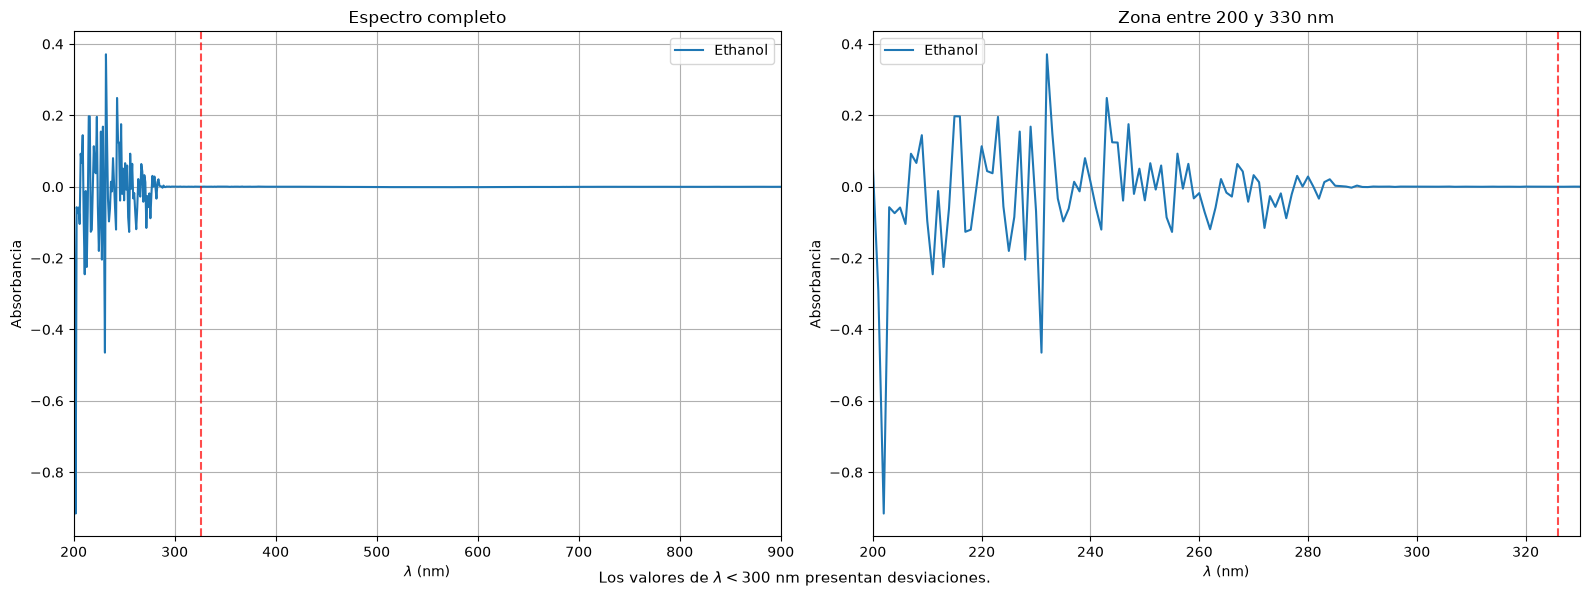

In [4]:
# Visualizamos la linea base (ethanol) en el rango entero, luego hacemos zoom en zonas de interés.
# Convertir los valores con coma decimal a números
ethanol_log = ethanol.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Espectro completo
ax1.plot(ethanol_log["lambda"], ethanol_log["A"], label="Ethanol")
ax1.set_xlim(
    ethanol_log["lambda"].min(),
    ethanol_log["lambda"].max()
)
ax1.set_xlabel(r"$\lambda$ (nm)")
ax1.set_ylabel("Absorbancia")
ax1.set_title("Espectro completo")
ax1.legend()
ax1.axvline(
    x=326,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Cambio de lámpara",
)
ax1.grid(True, which="both")

# Zona de interés
ax2.plot(ethanol_log["lambda"], ethanol_log["A"], label="Ethanol")
ax2.set_xlim(200, 330)
ax2.set_xlabel(r"$\lambda$ (nm)")
ax2.set_ylabel("Absorbancia")
ax2.set_title("Zona entre 200 y 330 nm")
ax2.legend()
ax2.axvline(
    x=326,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Cambio de lámpara",
)
ax2.grid(True, which="both")
fig.text(
    0.5,
    0.02,
    r"Los valores de ${\lambda} < 300$ nm presentan desviaciones.",
    ha="center",
    fontsize=11
)

fig.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

# Analizando los datos de absorbancia de los diferentes compuestos

## DOCI

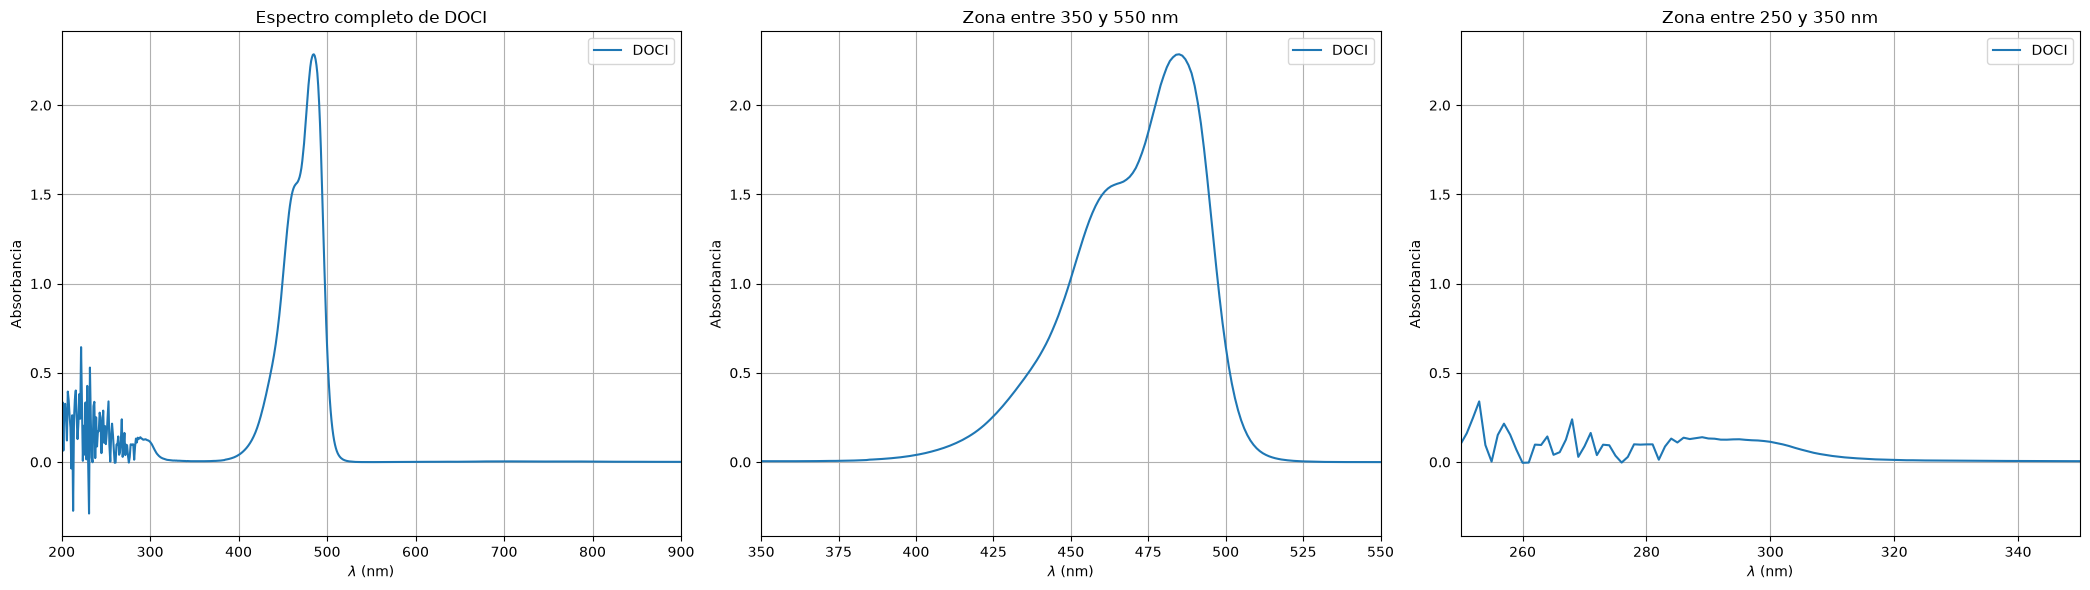

In [5]:
# Visualizamos los datos enteros de absorbancia de DOCI, luego recortamos en picos de interés.
doci_plot = doci.copy()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

# Espectro completo
ax1.plot(doci_plot["lambda"], doci_plot["A"], label="DOCI")
ax1.set_xlim(doci_plot["lambda"].min(), doci_plot["lambda"].max())
ax1.set_xlabel(r"$\lambda$ (nm)")
ax1.set_ylabel("Absorbancia")
ax1.set_title("Espectro completo de DOCI")
ax1.legend()
ax1.grid(True, which="both")

# Primera zona de interés
ax2.plot(doci_plot["lambda"], doci_plot["A"], label="DOCI")
ax2.set_xlim(350, 550)
ax2.set_xlabel(r"$\lambda$ (nm)")
ax2.set_ylabel("Absorbancia")
ax2.set_title("Zona entre 350 y 550 nm")
ax2.legend()
ax2.grid(True, which="both")

# Segunda zona de interés
ax3.plot(doci_plot["lambda"], doci_plot["A"], label="DOCI")
ax3.set_xlim(250, 350)
ax3.set_xlabel(r"$\lambda$ (nm)")
ax3.set_ylabel("Absorbancia")
ax3.set_title("Zona entre 250 y 350 nm")
ax3.legend()
ax3.grid(True, which="both")

plt.tight_layout()
plt.show()
 

In [6]:
# Recorto solo los datos de absorbancia de DOCI en la zona de interés (350-550 nm) para el ajuste de curva.
doci_fit = doci[(doci["lambda"] >= 350) & (doci["lambda"] <= 550)].copy()
doci_fit = doci_fit.sort_values("lambda").reset_index(drop=True)

# Visualización rápida del segmento seleccionado (opcional)
# plt.plot(doci_fit["lambda"], doci_fit["A"], marker="o")
# plt.xlabel(r"$\lambda$ (nm)")
# plt.ylabel("Absorbancia")
# plt.title("DOCI en 350-550 nm")
# plt.grid(True)
# plt.show()


Parámetros ajustados:
Gaussiana 1: amplitud=1.487, centro=465.03 nm, sigma=18.81 nm
Gaussiana 2: amplitud=1.541, centro=487.01 nm, sigma=8.05 nm
Fondo: 0.01589


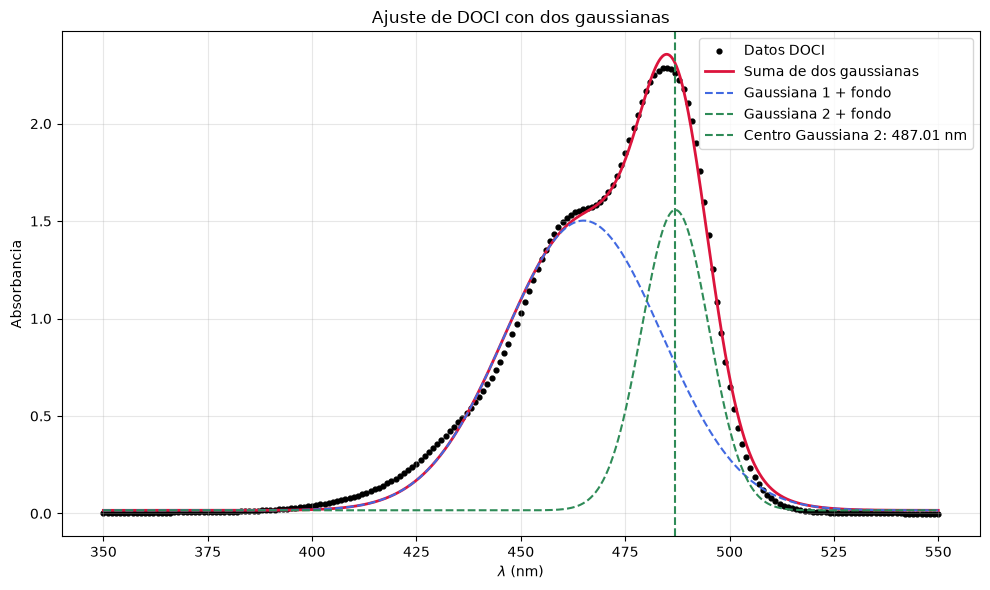

In [7]:
from scipy.optimize import curve_fit

# Modelo: suma de dos gaussianas con centros independientes y un nivel de fondo.
def doble_gaussiana(x, amplitud_1, centro_1, sigma_1, amplitud_2, centro_2, sigma_2, fondo):
    gaussiana_1 = amplitud_1 * np.exp(-((x - centro_1) ** 2) / (2 * sigma_1**2))
    gaussiana_2 = amplitud_2 * np.exp(-((x - centro_2) ** 2) / (2 * sigma_2**2))
    return fondo + gaussiana_1 + gaussiana_2

x = doci_fit["lambda"].to_numpy()
y = doci_fit["A"].to_numpy()

# Estimaciones iniciales: máximo de cada mitad del intervalo seleccionado.
mitad = np.median(x)
primer_pico = doci_fit[x <= mitad].loc[:, ["lambda", "A"]].iloc[
    doci_fit[x <= mitad]["A"].argmax()
]
segundo_pico = doci_fit[x > mitad].loc[:, ["lambda", "A"]].iloc[
    doci_fit[x > mitad]["A"].argmax()
]
fondo_inicial = float(y.min())
parametros_iniciales = [
    float(primer_pico["A"] - fondo_inicial), float(primer_pico["lambda"]), 20.0,
    float(segundo_pico["A"] - fondo_inicial), float(segundo_pico["lambda"]), 20.0,
    fondo_inicial,
]

limites_inferiores = [0, x.min(), 1e-6, 0, x.min(), 1e-6, -np.inf]
limites_superiores = [np.inf, x.max(), np.inf, np.inf, x.max(), np.inf, np.inf]
parametros, covarianza = curve_fit(
    doble_gaussiana,
    x,
    y,
    p0=parametros_iniciales,
    bounds=(limites_inferiores, limites_superiores),
    maxfev=50000,
)

x_modelo = np.linspace(x.min(), x.max(), 1000)
y_modelo = doble_gaussiana(x_modelo, *parametros)
y_gaussiana_1 = parametros[6] + parametros[0] * np.exp(
    -((x_modelo - parametros[1]) ** 2) / (2 * parametros[2] ** 2)
)
y_gaussiana_2 = parametros[6] + parametros[3] * np.exp(
    -((x_modelo - parametros[4]) ** 2) / (2 * parametros[5] ** 2)
)

print("Parámetros ajustados:")
print(f"Gaussiana 1: amplitud={parametros[0]:.4g}, centro={parametros[1]:.2f} nm, sigma={parametros[2]:.2f} nm")
print(f"Gaussiana 2: amplitud={parametros[3]:.4g}, centro={parametros[4]:.2f} nm, sigma={parametros[5]:.2f} nm")
print(f"Fondo: {parametros[6]:.4g}")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=12, color="black", label="Datos DOCI")
plt.plot(x_modelo, y_modelo, color="crimson", linewidth=2, label="Suma de dos gaussianas")
plt.plot(x_modelo, y_gaussiana_1, "--", color="royalblue", label="Gaussiana 1 + fondo")
plt.plot(x_modelo, y_gaussiana_2, "--", color="seagreen", label="Gaussiana 2 + fondo")
# linea vertical en el centro de la segunda gaussiana
plt.axvline(x=parametros[4], color="seagreen", linestyle="--", label=f"Centro Gaussiana 2: {parametros[4]:.2f} nm")
plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Absorbancia")
plt.title("Ajuste de DOCI con dos gaussianas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Parámetros del modelo combinado:
Asimétrica izquierda: amplitud=1.667, centro=474.37 nm
  sigma izquierda=24.77 nm, sigma derecha=13.09 nm
Simétrica derecha: amplitud=1.294, centro=489.06 nm, sigma=7.22 nm
Fondo: 0.009367
RMSE: 0.02643


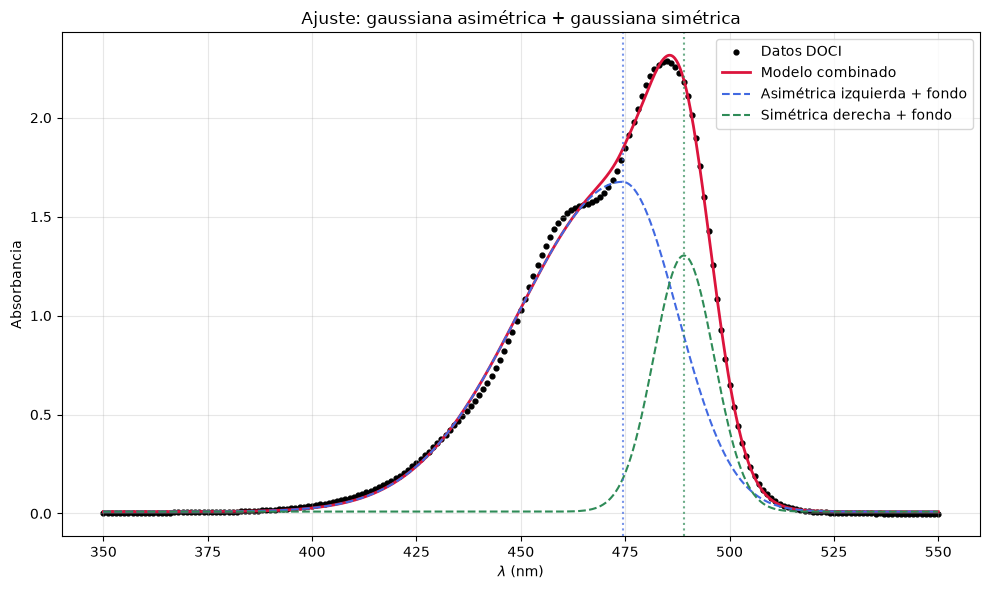

In [8]:
# Modelo combinado: gaussiana asimétrica a la izquierda + gaussiana simétrica a la derecha.
def asimetrica_mas_simetrica(
    x,
    amplitud_izquierda,
    centro_izquierda,
    sigma_izquierda,
    sigma_derecha_izquierda,
    amplitud_derecha,
    centro_derecha,
    sigma_derecha,
    fondo,
):
    sigma_izquierda_x = np.where(
        x < centro_izquierda,
        sigma_izquierda,
        sigma_derecha_izquierda,
    )
    componente_izquierda = amplitud_izquierda * np.exp(
        -((x - centro_izquierda) ** 2) / (2 * sigma_izquierda_x**2)
    )
    componente_derecha = amplitud_derecha * np.exp(
        -((x - centro_derecha) ** 2) / (2 * sigma_derecha**2)
    )
    return fondo + componente_izquierda + componente_derecha

parametros_iniciales_combinado = [1.6, 465.0, 30.0, 15.0, 1.5, 487.0, 8.0, 0.0]
limites_inferiores_combinado = [0, 420, 1e-6, 1e-6, 0, 475, 1e-6, -np.inf]
limites_superiores_combinado = [np.inf, 475, np.inf, np.inf, np.inf, 510, np.inf, np.inf]

parametros_combinado, covarianza_combinado = curve_fit(
    asimetrica_mas_simetrica,
    x,
    y,
    p0=parametros_iniciales_combinado,
    bounds=(limites_inferiores_combinado, limites_superiores_combinado),
    maxfev=100000,
)

x_modelo_combinado = np.linspace(x.min(), x.max(), 1000)
y_modelo_combinado = asimetrica_mas_simetrica(x_modelo_combinado, *parametros_combinado)
residuos_combinado = y - asimetrica_mas_simetrica(x, *parametros_combinado)
rmse_combinado = np.sqrt(np.mean(residuos_combinado**2))

amplitud_i, centro_i, sigma_i, sigma_i_derecha, amplitud_d, centro_d, sigma_d, fondo_c = parametros_combinado
sigma_i_x_modelo = np.where(
    x_modelo_combinado < centro_i,
    sigma_i,
    sigma_i_derecha,
)
componente_i_modelo = fondo_c + amplitud_i * np.exp(
    -((x_modelo_combinado - centro_i) ** 2) / (2 * sigma_i_x_modelo**2)
)
componente_d_modelo = fondo_c + amplitud_d * np.exp(
    -((x_modelo_combinado - centro_d) ** 2) / (2 * sigma_d**2)
)

print("Parámetros del modelo combinado:")
print(f"Asimétrica izquierda: amplitud={amplitud_i:.4g}, centro={centro_i:.2f} nm")
print(f"  sigma izquierda={sigma_i:.2f} nm, sigma derecha={sigma_i_derecha:.2f} nm")
print(f"Simétrica derecha: amplitud={amplitud_d:.4g}, centro={centro_d:.2f} nm, sigma={sigma_d:.2f} nm")
print(f"Fondo: {fondo_c:.4g}")
print(f"RMSE: {rmse_combinado:.5f}")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=12, color="black", label="Datos DOCI")
plt.plot(x_modelo_combinado, y_modelo_combinado, color="crimson", linewidth=2, label="Modelo combinado")
plt.plot(x_modelo_combinado, componente_i_modelo, "--", color="royalblue", label="Asimétrica izquierda + fondo")
plt.plot(x_modelo_combinado, componente_d_modelo, "--", color="seagreen", label="Simétrica derecha + fondo")
plt.axvline(centro_i, color="royalblue", linestyle=":", alpha=0.7)
plt.axvline(centro_d, color="seagreen", linestyle=":", alpha=0.7)
plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Absorbancia")
plt.title("Ajuste: gaussiana asimétrica + gaussiana simétrica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Parámetros del ajuste con tres gaussianas:
Gaussiana 1: amplitud=0.4039, centro=444.09 nm, sigma=19.00 nm
Gaussiana 2: amplitud=1.279, centro=465.36 nm, sigma=13.16 nm
Gaussiana 3: amplitud=1.937, centro=487.11 nm, sigma=8.66 nm
Fondo: 0.004589
RMSE: 0.01689
lambda_max = 485.07 +/- 0.12 nm
A_max = 2.344


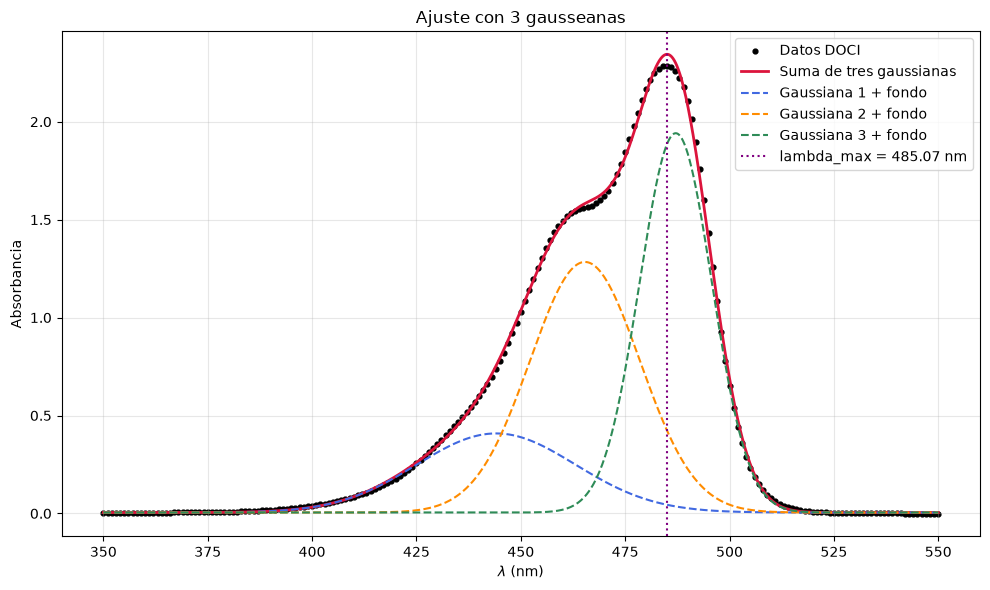

In [9]:
# Modelo alternativo: banda ancha + hombro + pico derecho.
def tres_gaussianas(
    x,
    amplitud_1,
    centro_1,
    sigma_1,
    amplitud_2,
    centro_2,
    sigma_2,
    amplitud_3,
    centro_3,
    sigma_3,
    fondo,
):
    gaussiana_1 = amplitud_1 * np.exp(-((x - centro_1) ** 2) / (2 * sigma_1**2))
    gaussiana_2 = amplitud_2 * np.exp(-((x - centro_2) ** 2) / (2 * sigma_2**2))
    gaussiana_3 = amplitud_3 * np.exp(-((x - centro_3) ** 2) / (2 * sigma_3**2))
    return fondo + gaussiana_1 + gaussiana_2 + gaussiana_3

# Inicialmente: banda ancha, hombro y pico estrecho de la derecha.
parametros_iniciales_tres = [1.2, 455.0, 25.0, 0.5, 468.0, 10.0, 1.3, 489.0, 8.0, 0.0]
limites_inferiores_tres = [0, 400, 5, 0, 450, 3, 0, 475, 3, -np.inf]
limites_superiores_tres = [np.inf, 470, 60, np.inf, 480, 25, np.inf, 510, 20, np.inf]

parametros_tres, covarianza_tres = curve_fit(
    tres_gaussianas,
    x,
    y,
    p0=parametros_iniciales_tres,
    bounds=(limites_inferiores_tres, limites_superiores_tres),
    maxfev=100000,
)

x_modelo_tres = np.linspace(x.min(), x.max(), 2000)
y_modelo_tres = tres_gaussianas(x_modelo_tres, *parametros_tres)
residuos_tres = y - tres_gaussianas(x, *parametros_tres)
rmse_tres = np.sqrt(np.mean(residuos_tres**2))

print("Parámetros del ajuste con tres gaussianas:")
for numero in range(3):
    indice = 3 * numero
    print(
        f"Gaussiana {numero + 1}: amplitud={parametros_tres[indice]:.4g}, "
        f"centro={parametros_tres[indice + 1]:.2f} nm, "
        f"sigma={parametros_tres[indice + 2]:.2f} nm"
    )
print(f"Fondo: {parametros_tres[9]:.4g}")
print(f"RMSE: {rmse_tres:.5f}")

# Máximo global del modelo ajustado en el intervalo medido.
indice_maximo = np.argmax(y_modelo_tres)
lambda_max = x_modelo_tres[indice_maximo]
A_max = y_modelo_tres[indice_maximo]

# Propagación de la incertidumbre de los parámetros a lambda_max.
rng = np.random.default_rng(12345)
parametros_simulados = rng.multivariate_normal(
    parametros_tres,
    covarianza_tres,
    size=1000,
)
lambda_max_simulados = []
x_modelo_simulacion = np.linspace(x.min(), x.max(), 3000)
for parametros_simulados_i in parametros_simulados:
    y_simulada = tres_gaussianas(x_modelo_simulacion, *parametros_simulados_i)
    lambda_max_simulados.append(x_modelo_simulacion[np.argmax(y_simulada)])

error_lambda_max = np.std(lambda_max_simulados, ddof=1)
print(f"lambda_max = {lambda_max:.2f} +/- {error_lambda_max:.2f} nm")
print(f"A_max = {A_max:.4g}")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=12, color="black", label="Datos DOCI")
plt.plot(x_modelo_tres, y_modelo_tres, color="crimson", linewidth=2, label="Suma de tres gaussianas")
for numero, color in zip(range(3), ["royalblue", "darkorange", "seagreen"]):
    indice = 3 * numero
    componente = parametros_tres[9] + parametros_tres[indice] * np.exp(
        -((x_modelo_tres - parametros_tres[indice + 1]) ** 2)
        / (2 * parametros_tres[indice + 2] ** 2)
    )
    plt.plot(x_modelo_tres, componente, "--", color=color, label=f"Gaussiana {numero + 1} + fondo")
plt.axvline(lambda_max, color="purple", linestyle=":", label=f"lambda_max = {lambda_max:.2f} nm")
plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Absorbancia")
plt.title("Ajuste con 3 gausseanas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
doci_lambda = int(lambda_max) # Redondeo de lambda_max a entero para usarlo en la tabla de resultados.
# Comparación entre el máximo experimental y el máximo de la curva ajustada.
indice_maximo_experimental = doci_fit["A"].idxmax()
lambda_max_experimental = doci_fit.loc[indice_maximo_experimental, "lambda"]
A_max_experimental = doci_fit.loc[indice_maximo_experimental, "A"]

print( 
    f"Máximo experimental: lambda_max = {lambda_max_experimental:.2f} +/- 1 nm, "
    f"A_max = {A_max_experimental:.4g}"
)
print(
    f"Máximo ajustado: lambda_max = {lambda_max:.2f} +/- {error_lambda_max:.2f} nm, "
    f"A_max = {A_max:.4g}"
)

Máximo experimental: lambda_max = 485.00 +/- 1 nm, A_max = 2.285
Máximo ajustado: lambda_max = 485.07 +/- 0.12 nm, A_max = 2.344


#### Resultados DOCI (p=5): ${\lambda_{max}}$ = 485.07 +/- 0.12 nm 

## DODCI (p=7)

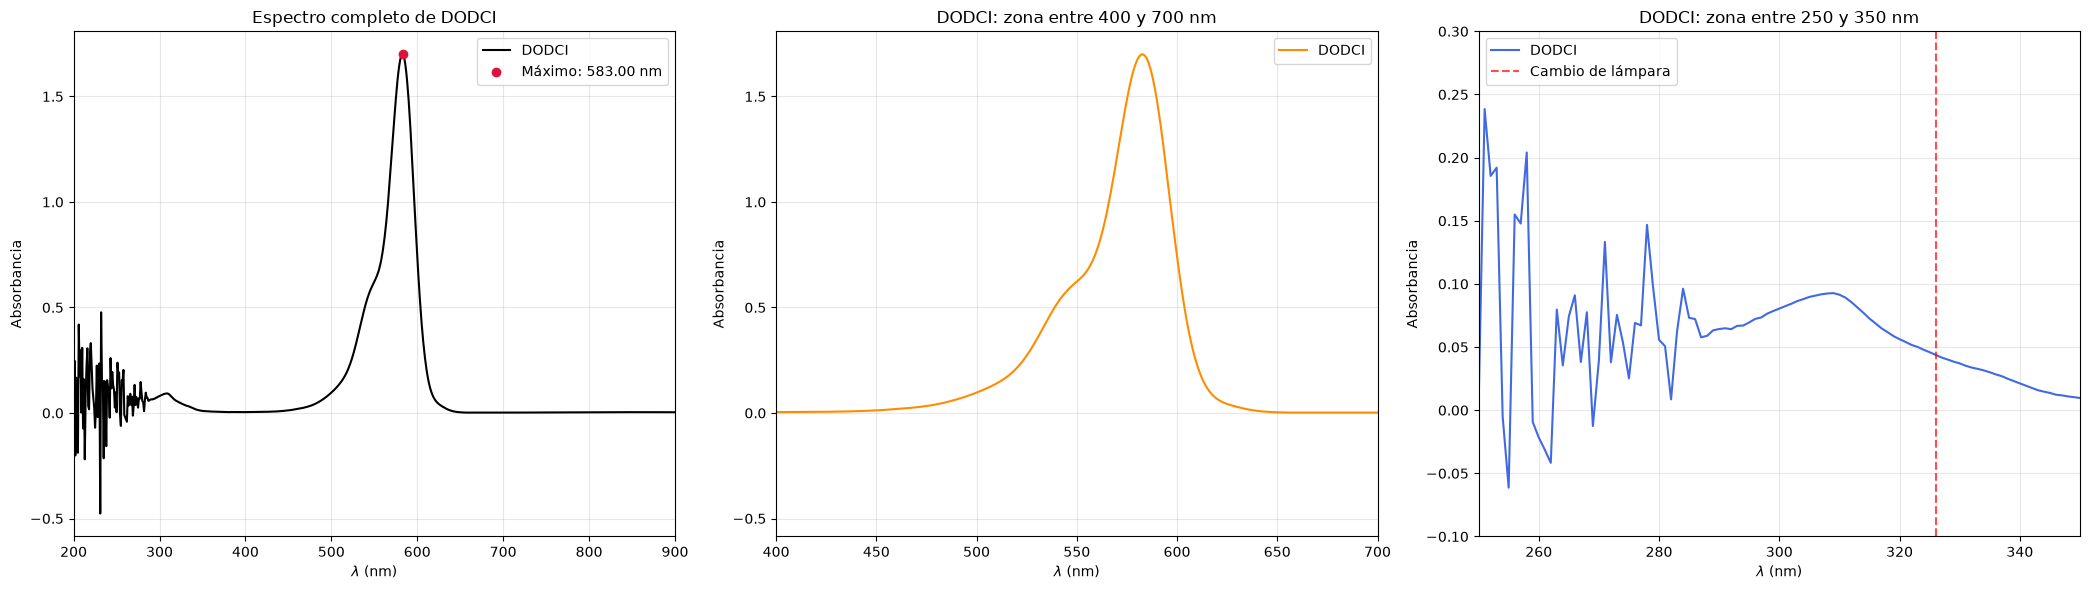

Máximo experimental de DODCI: lambda_max = 583.00 nm, A_max = 1.7


In [11]:
## DODCI

# Visualizamos el espectro completo de DODCI y dos zonas de interés.
dodci_plot = dodci.copy()
indice_maximo_dodci = dodci_plot["A"].idxmax()
lambda_max_dodci_experimental = dodci_plot.loc[indice_maximo_dodci, "lambda"]
A_max_dodci_experimental = dodci_plot.loc[indice_maximo_dodci, "A"]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

# Espectro completo
ax1.plot(dodci_plot["lambda"], dodci_plot["A"], color="black", label="DODCI")
ax1.scatter(
    lambda_max_dodci_experimental,
    A_max_dodci_experimental,
    color="crimson",
    zorder=3,
    label=f"Máximo: {lambda_max_dodci_experimental:.2f} nm",
)
ax1.set_xlim(dodci_plot["lambda"].min(), dodci_plot["lambda"].max())
ax1.set_xlabel(r"$\lambda$ (nm)")
ax1.set_ylabel("Absorbancia")
ax1.set_title("Espectro completo de DODCI")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Banda principal
ax2.plot(dodci_plot["lambda"], dodci_plot["A"], color="darkorange", label="DODCI")
ax2.set_xlim(400, 700)
ax2.set_xlabel(r"$\lambda$ (nm)")
ax2.set_ylabel("Absorbancia")
ax2.set_title("DODCI: zona entre 400 y 700 nm")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Región UV
ax3.plot(dodci_plot["lambda"], dodci_plot["A"], color="royalblue", label="DODCI")
# Agregar linea vertical en x=326 correspondiente a cambio de lampara
ax3.axvline(x=326, color="red", linestyle="--", alpha=0.7, label="Cambio de lámpara")
ax3.set_xlim(250, 350)
ax3.set_ylim(-0.1, 0.3)
ax3.set_xlabel(r"$\lambda$ (nm)")
ax3.set_ylabel("Absorbancia")
ax3.set_title("DODCI: zona entre 250 y 350 nm")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Máximo experimental de DODCI: lambda_max = "
    f"{lambda_max_dodci_experimental:.2f} nm, "
    f"A_max = {A_max_dodci_experimental:.4g}"
)

Parámetros del ajuste de DODCI con tres gaussianas:
Gaussiana 1: amplitud=0.1936, centro=547.94 nm, sigma=38.73 nm
Gaussiana 2: amplitud=0.382, centro=549.64 nm, sigma=15.66 nm
Gaussiana 3: amplitud=1.537, centro=583.49 nm, sigma=12.71 nm
Fondo: 0.002195
RMSE: 0.00322
lambda_max ajustado = 582.56 +/- 0.03 nm
A_max ajustado = 1.707


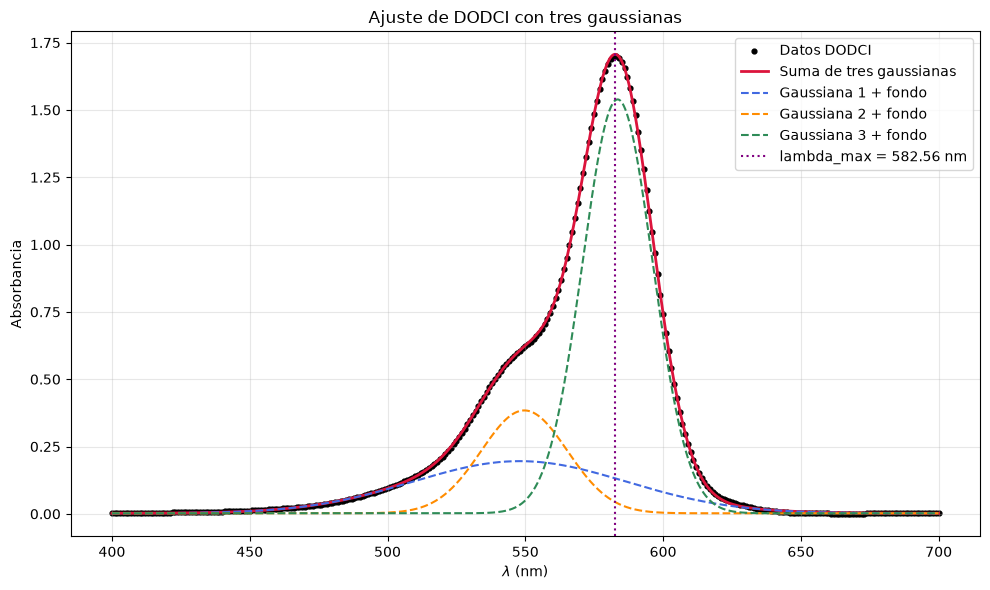

In [12]:
# Recorte de DODCI para ajustar la banda principal.
dodci_fit = dodci[(dodci["lambda"] >= 400) & (dodci["lambda"] <= 700)].copy()
dodci_fit = dodci_fit.sort_values("lambda").reset_index(drop=True)
x_dodci = dodci_fit["lambda"].to_numpy()
y_dodci = dodci_fit["A"].to_numpy()

# Mismo modelo usado para DOCI: banda ancha, hombro y pico principal.
parametros_iniciales_dodci = [0.5, 530.0, 45.0, 0.3, 560.0, 20.0, 1.5, 583.0, 12.0, 0.0]
limites_inferiores_dodci = [0, 450, 5, 0, 500, 3, 0, 560, 3, -np.inf]
limites_superiores_dodci = [np.inf, 570, 100, np.inf, 600, 50, np.inf, 620, 40, np.inf]

parametros_dodci, covarianza_dodci = curve_fit(
    tres_gaussianas,
    x_dodci,
    y_dodci,
    p0=parametros_iniciales_dodci,
    bounds=(limites_inferiores_dodci, limites_superiores_dodci),
    maxfev=100000,
)

x_modelo_dodci = np.linspace(x_dodci.min(), x_dodci.max(), 3000)
y_modelo_dodci = tres_gaussianas(x_modelo_dodci, *parametros_dodci)
residuos_dodci = y_dodci - tres_gaussianas(x_dodci, *parametros_dodci)
rmse_dodci = np.sqrt(np.mean(residuos_dodci**2))

print("Parámetros del ajuste de DODCI con tres gaussianas:")
for numero in range(3):
    indice = 3 * numero
    print(
        f"Gaussiana {numero + 1}: amplitud={parametros_dodci[indice]:.4g}, "
        f"centro={parametros_dodci[indice + 1]:.2f} nm, "
        f"sigma={parametros_dodci[indice + 2]:.2f} nm"
    )
print(f"Fondo: {parametros_dodci[9]:.4g}")
print(f"RMSE: {rmse_dodci:.5f}")

# Máximo global de la suma ajustada.
indice_maximo_dodci = np.argmax(y_modelo_dodci)
lambda_max_dodci = x_modelo_dodci[indice_maximo_dodci]
A_max_dodci = y_modelo_dodci[indice_maximo_dodci]

# Incertidumbre de lambda_max mediante simulación de la covarianza.
rng_dodci = np.random.default_rng(12345)
parametros_simulados_dodci = rng_dodci.multivariate_normal(
    parametros_dodci,
    covarianza_dodci,
    size=2000,
)
x_modelo_simulacion_dodci = np.linspace(x_dodci.min(), x_dodci.max(), 5000)
lambda_max_simulados_dodci = []
for parametros_simulados_i in parametros_simulados_dodci:
    y_simulada = tres_gaussianas(x_modelo_simulacion_dodci, *parametros_simulados_i)
    lambda_max_simulados_dodci.append(
        x_modelo_simulacion_dodci[np.argmax(y_simulada)]
    )
error_lambda_max_dodci = np.std(lambda_max_simulados_dodci, ddof=1)
print(f"lambda_max ajustado = {lambda_max_dodci:.2f} +/- {error_lambda_max_dodci:.2f} nm")
print(f"A_max ajustado = {A_max_dodci:.4g}")

plt.figure(figsize=(10, 6))
plt.scatter(x_dodci, y_dodci, s=12, color="black", label="Datos DODCI")
plt.plot(x_modelo_dodci, y_modelo_dodci, color="crimson", linewidth=2, label="Suma de tres gaussianas")
for numero, color in zip(range(3), ["royalblue", "darkorange", "seagreen"]):
    indice = 3 * numero
    componente = parametros_dodci[9] + parametros_dodci[indice] * np.exp(
        -((x_modelo_dodci - parametros_dodci[indice + 1]) ** 2)
        / (2 * parametros_dodci[indice + 2] ** 2)
    )
    plt.plot(
        x_modelo_dodci,
        componente,
        "--",
        color=color,
        label=f"Gaussiana {numero + 1} + fondo",
    )
plt.axvline(
    lambda_max_dodci,
    color="purple",
    linestyle=":",
    label=f"lambda_max = {lambda_max_dodci:.2f} nm",
)
plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Absorbancia")
plt.title("Ajuste de DODCI con tres gaussianas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Comparación de los dos lambda obtenidos para DODCI.
diferencia_dodci = lambda_max_dodci - lambda_max_dodci_experimental

print("Comparación de lambda_max para DODCI:")
print(
    f"Máximo experimental: lambda_max = "
    f"{lambda_max_dodci_experimental:.2f} +/- 1.00 nm"
)
print(
    f"Máximo ajustado:     lambda_max = "
    f"{lambda_max_dodci:.2f} +/- {error_lambda_max_dodci:.2f} nm"
)
print(f"Diferencia ajuste - experimento: {diferencia_dodci:+.2f} nm")

Comparación de lambda_max para DODCI:
Máximo experimental: lambda_max = 583.00 +/- 1.00 nm
Máximo ajustado:     lambda_max = 582.56 +/- 0.03 nm
Diferencia ajuste - experimento: -0.44 nm


#### Resultados DODCI (p=7): ${\lambda_{max}}$ = 582.56 +/- 0.03 nm

## DOTC (p=9)

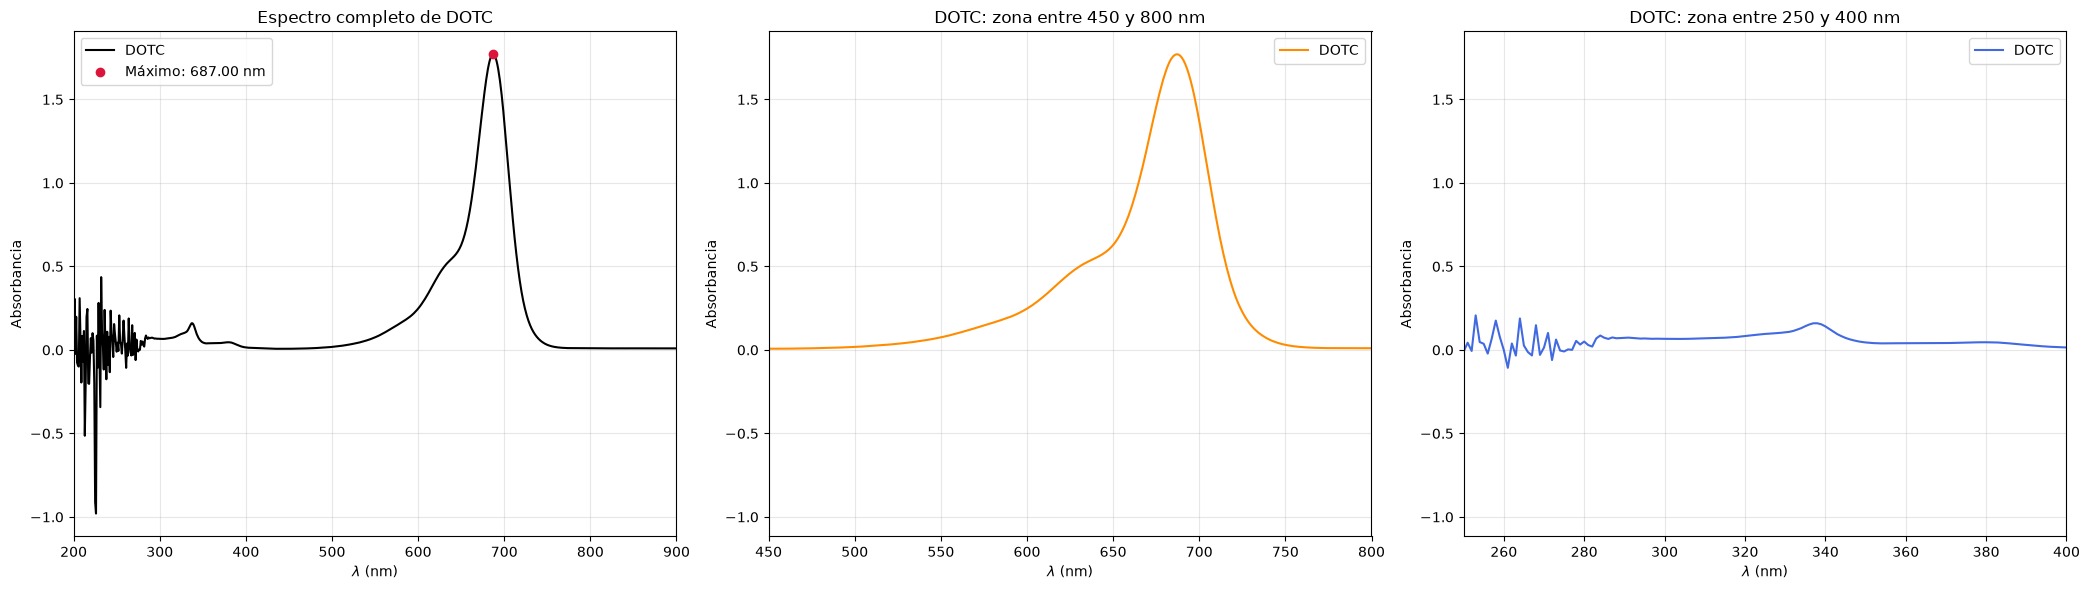

Máximo experimental de DOTC: lambda_max = 687.00 nm, A_max = 1.77


In [14]:
## DOTC

# Visualizamos el espectro completo de DOTC y dos zonas de interés.
dotc_plot = dotc.copy()
indice_maximo_dotc_experimental = dotc_plot["A"].idxmax()
lambda_max_dotc_experimental = dotc_plot.loc[indice_maximo_dotc_experimental, "lambda"]
A_max_dotc_experimental = dotc_plot.loc[indice_maximo_dotc_experimental, "A"]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

# Espectro completo
ax1.plot(dotc_plot["lambda"], dotc_plot["A"], color="black", label="DOTC")
ax1.scatter(
    lambda_max_dotc_experimental,
    A_max_dotc_experimental,
    color="crimson",
    zorder=3,
    label=f"Máximo: {lambda_max_dotc_experimental:.2f} nm",
)
ax1.set_xlim(dotc_plot["lambda"].min(), dotc_plot["lambda"].max())
ax1.set_xlabel(r"$\lambda$ (nm)")
ax1.set_ylabel("Absorbancia")
ax1.set_title("Espectro completo de DOTC")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Banda visible principal
ax2.plot(dotc_plot["lambda"], dotc_plot["A"], color="darkorange", label="DOTC")
ax2.set_xlim(450, 800)
ax2.set_xlabel(r"$\lambda$ (nm)")
ax2.set_ylabel("Absorbancia")
ax2.set_title("DOTC: zona entre 450 y 800 nm")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Región UV
ax3.plot(dotc_plot["lambda"], dotc_plot["A"], color="royalblue", label="DOTC")
ax3.set_xlim(250, 400)
ax3.set_xlabel(r"$\lambda$ (nm)")
ax3.set_ylabel("Absorbancia")
ax3.set_title("DOTC: zona entre 250 y 400 nm")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Máximo experimental de DOTC: lambda_max = "
    f"{lambda_max_dotc_experimental:.2f} nm, "
    f"A_max = {A_max_dotc_experimental:.4g}"
)

Parámetros del ajuste de DOTC con tres gaussianas:
Gaussiana 1: amplitud=0.262, centro=638.37 nm, sigma=54.14 nm
Gaussiana 2: amplitud=0.2607, centro=642.27 nm, sigma=21.90 nm
Gaussiana 3: amplitud=1.56, centro=688.03 nm, sigma=16.85 nm
Fondo: 0.007874
RMSE: 0.00338
lambda_max ajustado = 686.98 +/- 0.03 nm
A_max ajustado = 1.773


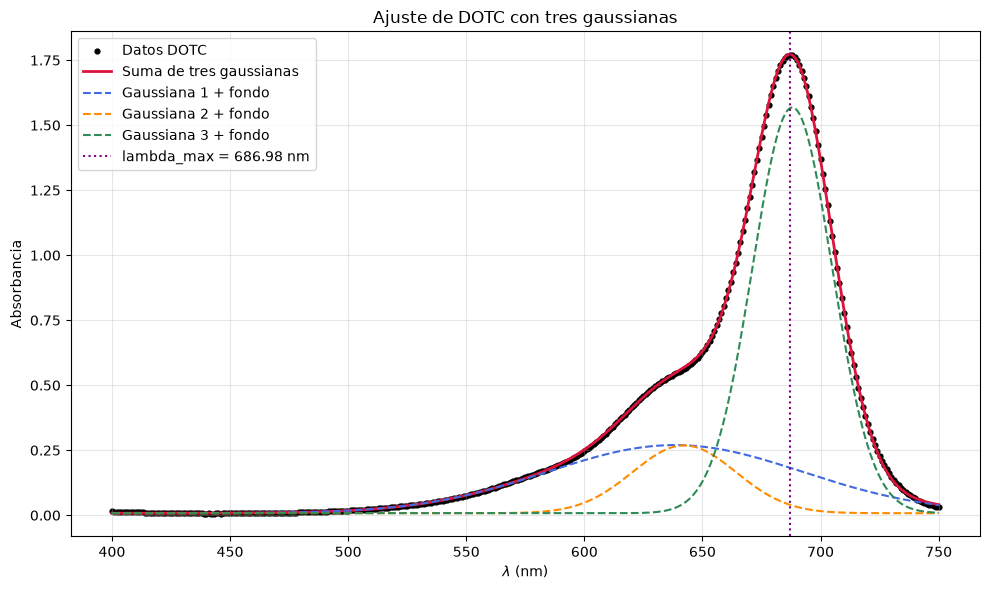

Comparación de lambda_max para DOTC:
Máximo experimental: lambda_max = 687.00 nm
Máximo ajustado:     lambda_max = 686.98 +/- 0.03 nm
Diferencia ajuste - experimento: -0.02 nm
Diferencia absoluta: 0.02 nm


In [15]:
# Recorte de DOTC para ajustar la banda principal.
dotc_fit = dotc[(dotc["lambda"] >= 400) & (dotc["lambda"] <= 750)].copy()
dotc_fit = dotc_fit.sort_values("lambda").reset_index(drop=True)
x_dotc = dotc_fit["lambda"].to_numpy()
y_dotc = dotc_fit["A"].to_numpy()

# Mismo modelo usado para DOCI y DODCI: banda ancha, hombro y pico principal.
parametros_iniciales_dotc = [0.5, 610.0, 70.0, 0.4, 645.0, 30.0, 1.5, 687.0, 15.0, 0.0]
limites_inferiores_dotc = [0, 500, 10, 0, 570, 5, 0, 660, 5, -np.inf]
limites_superiores_dotc = [np.inf, 650, 150, np.inf, 680, 80, np.inf, 720, 50, np.inf]

parametros_dotc, covarianza_dotc = curve_fit(
    tres_gaussianas,
    x_dotc,
    y_dotc,
    p0=parametros_iniciales_dotc,
    bounds=(limites_inferiores_dotc, limites_superiores_dotc),
    maxfev=100000,
)

x_modelo_dotc = np.linspace(x_dotc.min(), x_dotc.max(), 3000)
y_modelo_dotc = tres_gaussianas(x_modelo_dotc, *parametros_dotc)
residuos_dotc = y_dotc - tres_gaussianas(x_dotc, *parametros_dotc)
rmse_dotc = np.sqrt(np.mean(residuos_dotc**2))

print("Parámetros del ajuste de DOTC con tres gaussianas:")
for numero in range(3):
    indice = 3 * numero
    print(
        f"Gaussiana {numero + 1}: amplitud={parametros_dotc[indice]:.4g}, "
        f"centro={parametros_dotc[indice + 1]:.2f} nm, "
        f"sigma={parametros_dotc[indice + 2]:.2f} nm"
    )
print(f"Fondo: {parametros_dotc[9]:.4g}")
print(f"RMSE: {rmse_dotc:.5f}")

# Máximo global de la suma ajustada.
indice_maximo_dotc = np.argmax(y_modelo_dotc)
lambda_max_dotc = x_modelo_dotc[indice_maximo_dotc]
A_max_dotc = y_modelo_dotc[indice_maximo_dotc]

# Incertidumbre de lambda_max mediante simulación de la covarianza.
rng_dotc = np.random.default_rng(12345)
parametros_simulados_dotc = rng_dotc.multivariate_normal(
    parametros_dotc,
    covarianza_dotc,
    size=2000,
)
x_modelo_simulacion_dotc = np.linspace(x_dotc.min(), x_dotc.max(), 5000)
lambda_max_simulados_dotc = []
for parametros_simulados_i in parametros_simulados_dotc:
    y_simulada = tres_gaussianas(x_modelo_simulacion_dotc, *parametros_simulados_i)
    lambda_max_simulados_dotc.append(
        x_modelo_simulacion_dotc[np.argmax(y_simulada)]
    )
error_lambda_max_dotc = np.std(lambda_max_simulados_dotc, ddof=1)
print(f"lambda_max ajustado = {lambda_max_dotc:.2f} +/- {error_lambda_max_dotc:.2f} nm")
print(f"A_max ajustado = {A_max_dotc:.4g}")

plt.figure(figsize=(10, 6))
plt.scatter(x_dotc, y_dotc, s=12, color="black", label="Datos DOTC")
plt.plot(x_modelo_dotc, y_modelo_dotc, color="crimson", linewidth=2, label="Suma de tres gaussianas")
for numero, color in zip(range(3), ["royalblue", "darkorange", "seagreen"]):
    indice = 3 * numero
    componente = parametros_dotc[9] + parametros_dotc[indice] * np.exp(
        -((x_modelo_dotc - parametros_dotc[indice + 1]) ** 2)
        / (2 * parametros_dotc[indice + 2] ** 2)
    )
    plt.plot(
        x_modelo_dotc,
        componente,
        "--",
        color=color,
        label=f"Gaussiana {numero + 1} + fondo",
    )
plt.axvline(
    lambda_max_dotc,
    color="purple",
    linestyle=":",
    label=f"lambda_max = {lambda_max_dotc:.2f} nm",
)
plt.xlabel(r"$\lambda$ (nm)")
plt.ylabel("Absorbancia")
plt.title("Ajuste de DOTC con tres gaussianas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparación entre el máximo experimental y el máximo ajustado.
diferencia_dotc = lambda_max_dotc - lambda_max_dotc_experimental
print("Comparación de lambda_max para DOTC:")
print(f"Máximo experimental: lambda_max = {lambda_max_dotc_experimental:.2f} nm")
print(
    f"Máximo ajustado:     lambda_max = {lambda_max_dotc:.2f} +/- "
    f"{error_lambda_max_dotc:.2f} nm"
)
print(f"Diferencia ajuste - experimento: {diferencia_dotc:+.2f} nm")
print(f"Diferencia absoluta: {abs(diferencia_dotc):.2f} nm")

#### Resultados DOTCI (p=9): ${\lambda_{max}}$ = 582.56 +/- 0.03 nm

## Resultados finales:
DOCI: ${\lambda_{max}}$ = 485.07 +/- 0.12 nm <br>
DODCI: ${\lambda_{max}}$ = 582.56 +/- 0.03 nm <br>
DOTCI: ${\lambda_{max}}$ = 686.98 +/- 0.03 nm 

# Grafico de lambda_max vs p

Con DOCI p=3, DODCI p=5 y DOTCI p=7

Valores utilizados:
p = 5: lambda_max = 485.07 +/- 0.12 nm
p = 7: lambda_max = 582.56 +/- 0.03 nm
p = 9: lambda_max = 686.98 +/- 0.03 nm

Ajuste lineal:
lambda_max(p) = (51.676 +/- 0.020) p + (221.48 +/- 0.16) nm
RMSE del ajuste lineal: 3.04 nm


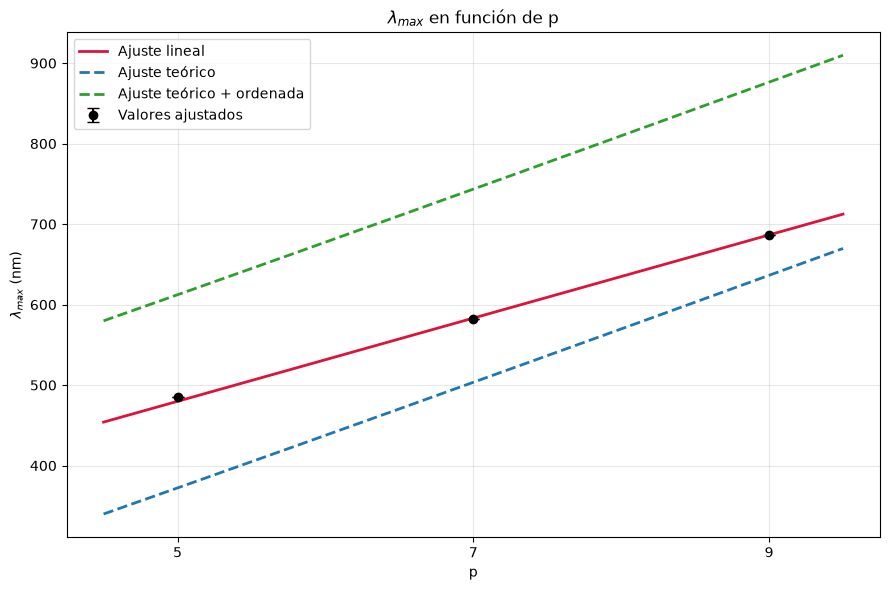

In [16]:
# Ajuste lineal de lambda_max en función de p.
p_valores = np.array([5, 7, 9], dtype=float)  # corregido
lambda_valores = np.array([lambda_max, lambda_max_dodci, lambda_max_dotc], dtype=float)
error_lambda_valores = np.array(
    [error_lambda_max, error_lambda_max_dodci, error_lambda_max_dotc],
    dtype=float,
)

# Modelo lineal: lambda_max = pendiente * p + ordenada_al_origen.
def ajuste_lineal(p, pendiente, ordenada_al_origen):
    return pendiente * p + ordenada_al_origen

parametros_lineales, covarianza_lineal = curve_fit(
    ajuste_lineal,
    p_valores,
    lambda_valores,
    sigma=error_lambda_valores,
    absolute_sigma=True,
)
pendiente, ordenada_al_origen = parametros_lineales
error_pendiente, error_ordenada = np.sqrt(np.diag(covarianza_lineal))

lambda_ajustada = ajuste_lineal(p_valores, *parametros_lineales)
residuos_lineales = lambda_valores - lambda_ajustada
rmse_lineal = np.sqrt(np.mean(residuos_lineales**2))

print("Valores utilizados:")
for p, lambda_maximo, error in zip(p_valores, lambda_valores, error_lambda_valores):
    print(f"p = {p:.0f}: lambda_max = {lambda_maximo:.2f} +/- {error:.2f} nm")

print("\nAjuste lineal:")
print(
    f"lambda_max(p) = ({pendiente:.3f} +/- {error_pendiente:.3f}) p "
    f"+ ({ordenada_al_origen:.2f} +/- {error_ordenada:.2f}) nm"
)
print(f"RMSE del ajuste lineal: {rmse_lineal:.2f} nm")

p_modelo_lineal = np.linspace(4.5, 9.5, 200)
lambda_modelo_lineal = ajuste_lineal(p_modelo_lineal, *parametros_lineales)

plt.figure(figsize=(9, 6))
plt.errorbar(
    p_valores,
    lambda_valores,
    yerr=error_lambda_valores,
    fmt="o",
    color="black",
    capsize=4,
    label="Valores ajustados",
)
plt.plot(
    p_modelo_lineal,
    lambda_modelo_lineal,
    color="crimson",
    linewidth=2,
    label="Ajuste lineal",
)

d_simple1 = 1.47e-10
d_doble1 = 1.35e-10
d_simple = 1.54e-10
d_doble = 1.34e-10
d = (d_simple + d_doble) / 2

# Gráfico lineal teórico
c = 299792458
m = 9.1093837015e-31
h = 6.62607015e-34

p_modelo_teorico = p_modelo_lineal
lambda_teorico_m = 8 * m * c * ((p_modelo_teorico + 2) * d) ** 2 / (h * (p_modelo_teorico + 4))
lambda_teorico_nm = lambda_teorico_m * 1e9

plt.plot(
    p_modelo_teorico,
    lambda_teorico_nm,
    color="tab:blue",
    linestyle="--",
    linewidth=2,
    label="Ajuste teórico",
)

plt.plot(
    p_modelo_teorico,
    lambda_teorico_nm + 240,
    color="tab:green",
    linestyle="--",
    linewidth=2,
    label="Ajuste teórico + ordenada",
)

plt.xticks(p_valores)
plt.xlabel("p")
plt.ylabel(r"$\lambda_{max}$ (nm)")
plt.title(r"$\lambda_{max}$ en función de p")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Agrego datos de TIO cianinas

# Nuevos datos TIO (máximo experimental)


In [17]:
# Importo datos de la carpeta con extension txt y con los datos empezando en la fila 3
dtci_tio = pd.read_csv("data_TIO_2025\File_250827_145425_DTCI.txt", sep="\t", header=None, names=["lambda", "A"], skiprows=2)
dtdc_tio = pd.read_csv("data_TIO_2025\File_250827_161311_DTDC.txt", sep="\t", header=None, names=["lambda", "A"], skiprows=2)
dttc_tio = pd.read_csv("data_TIO_2025\File_250827_163657DTTC.txt", sep="\t", header=None, names=["lambda", "A"], skiprows=2)

<>:2: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:3: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:4: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:2: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:3: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:4: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
C:\Users\nacho\AppData\Local\Temp\ipykernel_12120\2018099987.py:2: SyntaxWarning: 

In [18]:
# Obtengo el lambda max para cada uno de los tres espectros de TIO
indice_maximo_dtci = dtci_tio["A"].idxmax()
indice_maximo_dtdc = dtdc_tio["A"].idxmax()
indice_maximo_dttc = dttc_tio["A"].idxmax()

DTCI-TIO: p=5, lambda_max = 559.00 nm
DTDC-TIO: p=7, lambda_max = 655.00 nm
DTTC-TIO: p=9, lambda_max = 761.00 nm


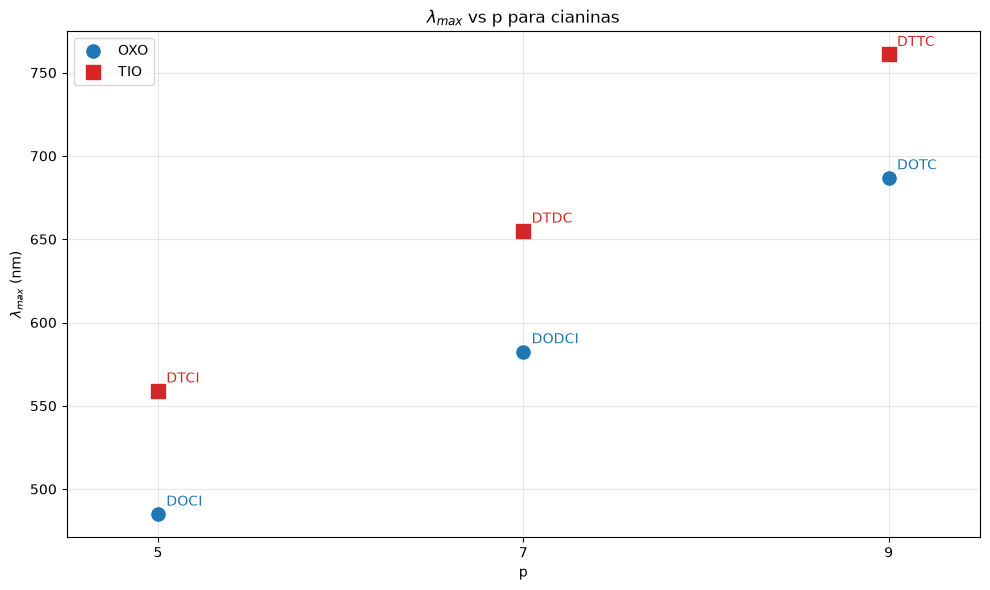

In [19]:
# Máximos experimentales de los TIO
lambda_max_dtci_tio = dtci_tio.loc[dtci_tio["A"].idxmax(), "lambda"]
lambda_max_dtdc_tio = dtdc_tio.loc[dtdc_tio["A"].idxmax(), "lambda"]
lambda_max_dttc_tio = dttc_tio.loc[dttc_tio["A"].idxmax(), "lambda"]

print(f"DTCI-TIO: p=5, lambda_max = {lambda_max_dtci_tio:.2f} nm")
print(f"DTDC-TIO: p=7, lambda_max = {lambda_max_dtdc_tio:.2f} nm")
print(f"DTTC-TIO: p=9, lambda_max = {lambda_max_dttc_tio:.2f} nm")

# Datos previos obtenidos con ajuste de gaussianas
p_previos = np.array([5.0, 7.0, 9.0], dtype=float)
lambda_previos = np.array([lambda_max, lambda_max_dodci, lambda_max_dotc], dtype=float)
labels_previos = ["DOCI", "DODCI", "DOTC"]

# Nuevos datos TIO
p_tio = np.array([5.0, 7.0, 9.0], dtype=float)
lambda_tio = np.array(
    [lambda_max_dtci_tio, lambda_max_dtdc_tio, lambda_max_dttc_tio],
    dtype=float,
)
labels_tio = ["DTCI", "DTDC", "DTTC"]

plt.figure(figsize=(10, 6))

# Datos previos
plt.scatter(
    p_previos,
    lambda_previos,
    s=90,
    color="tab:blue",
    label="OXO",
    zorder=3,
)
for p_i, lam_i, label in zip(p_previos, lambda_previos, labels_previos):
    plt.annotate(
        label,
        (p_i, lam_i),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        color="tab:blue",
    )

# Nuevos datos TIO
plt.scatter(
    p_tio,
    lambda_tio,
    s=90,
    color="tab:red",
    marker="s",
    label="TIO",
    zorder=3,
)
for p_i, lam_i, label in zip(p_tio, lambda_tio, labels_tio):
    plt.annotate(
        label,
        (p_i, lam_i),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        color="tab:red",
    )

plt.xlabel("p")
plt.ylabel(r"$\lambda_{max}$ (nm)")
plt.title(r"$\lambda_{max}$ vs p para cianinas")
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(5, 10, 2))
plt.xlim(4.5, 9.5)
plt.legend()
plt.tight_layout()
plt.show()

# Correcion de modelo: pozo finito (potencial V0 y ancho a)

# Finite square well model

Para cada cadena p, resolvemos numéricamente las ecuaciones de contorno del pozo finito y usamos la diferencia entre los dos primeros niveles ligados como transición óptica dominante. En esta convención, la longitud de onda se obtiene con la relación $\lambda = 1240 / \Delta E$.

Las ecuaciones relevantes son:

$\tan(\theta) = \sqrt{\frac{\theta_0^2}{\theta^2} - 1}$ para estados pares

$-\cot(\theta) = \sqrt{\frac{\theta_0^2}{\theta^2} - 1}$ para estados impares

con $\theta = kL/2$ y $\theta_0 = \theta(V_0, L)$.


<>:117: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:117: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\nacho\AppData\Local\Temp\ipykernel_972\1002381106.py:117: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Longitud de onda $\lambda$ [nm]', fontsize=12)


V0 optimizado para OXO Cianinas: 9.13 eV
V0 optimizado para TIO Cianinas: 7.23 eV


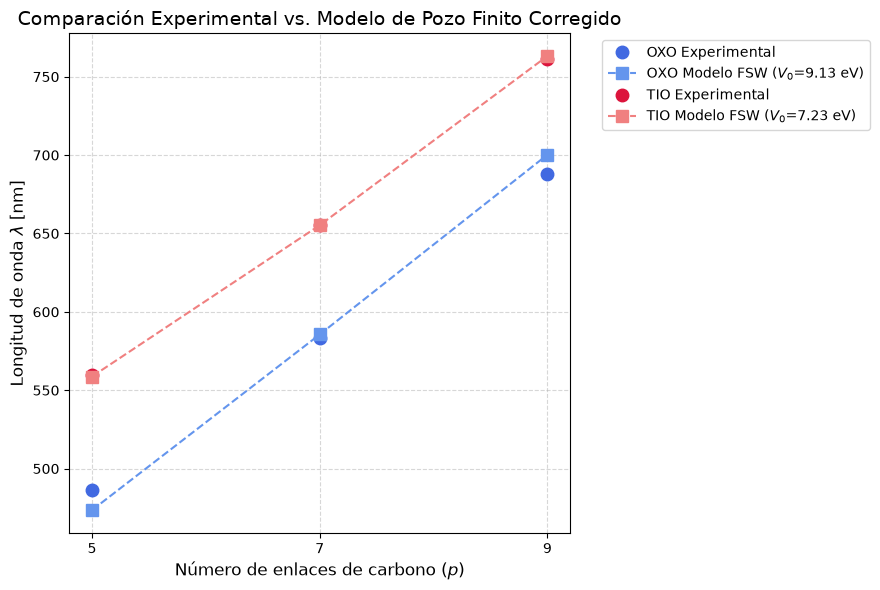

In [4]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# --- 1. Constantes Universales y Funciones Base ---
hbar = 6.582119569e-16 # eV * s
m_e = 510.998e3 / 299792458**2 # eV / (m/s)^2

def get_chain_length(p):
    return (p + 2) * 0.134 # nm

def swap_ev_and_nm(v):
    return 1240 / v

def get_fsw_theta(e, l):
    return np.sqrt(2 * m_e * e) / hbar * (l * 1e-9 / 2)

def get_fsw_energy(theta, l):
    return 2 * hbar**2 * theta**2 / (m_e * (l * 1e-9)**2)

# --- 2. CORRECCIÓN FUNDAMENTAL: Filtrar ramas negativas y asíntotas ---
def fsw_even_fn(theta):
    val = np.tan(theta)
    return np.nan if val < 0 else val # Solo ramas positivas

def fsw_odd_fn(theta):
    val = -1 / np.tan(theta)
    return np.nan if val < 0 else val # Solo ramas positivas

def fsw_g(theta, theta0):
    if theta >= theta0: return np.nan # Evitar raíces de números negativos
    return np.sqrt((theta0 / theta)**2 - 1)

def find_all_roots(f, x_min, x_max, n_steps=2000):
    step = (x_max - x_min) / n_steps
    xs = np.arange(x_min, x_max, step)
    roots = []
    for x1, x2 in zip(xs[:-1], xs[1:]):
        y1, y2 = f(x1), f(x2)
        # Ignorar intervalos que contengan asíntotas filtradas (NaNs)
        if np.isnan(y1) or np.isnan(y2):
            continue
        if y1 == 0: roots.append(x1)
        elif y2 == 0: roots.append(x2)
        elif y1 * y2 < 0:
            try:
                roots.append(opt.brentq(f, x1, x2))
            except ValueError:
                pass
    return np.unique(np.round(roots, 10))

# --- 3. Cálculo de Energías y Transición ---
def get_cyanines_fsw_energies(v0, p):
    theta0 = get_fsw_theta(e=v0, l=get_chain_length(p))
    search_min, search_max = 1e-4, theta0
    
    even_zeros = find_all_roots(lambda theta: fsw_even_fn(theta) - fsw_g(theta, theta0), search_min, search_max)
    odd_zeros = find_all_roots(lambda theta: fsw_odd_fn(theta) - fsw_g(theta, theta0), search_min, search_max)
    
    all_roots = np.array(list(even_zeros) + list(odd_zeros))
    return sorted(get_fsw_energy(all_roots, get_chain_length(p)))

def get_homo_lumo_transition(energies, p):
    n_electrons = p + 3
    # Asegurarnos de que el pozo tiene suficientes estados ligados para acomodar los electrones
    if len(energies) < n_electrons / 2 + 1: return np.nan
    homo_e = energies[int(n_electrons // 2) - 1]
    lumo_e = energies[int(n_electrons // 2)]
    return lumo_e - homo_e

# --- 4. Optimización con los Datos Experimentales ---
spectrums_mu_d = {
    'OXO': {5: 486.36, 7: 583.18, 9: 687.75},
    'TIO': {5: 559.80, 7: 655.34, 9: 761.37}
}

def fsw_chi2(v0, series):
    total = 0
    for p, mu_d in spectrums_mu_d[series].items():
        energies = get_cyanines_fsw_energies(v0, p)
        transition_e = get_homo_lumo_transition(energies, p)
        
        # Fuerte penalización si V0 es tan bajo que los electrones no caben
        if np.isnan(transition_e):
            total += 1e6 
        else:
            model_e = swap_ev_and_nm(transition_e)
            total += (mu_d - model_e) ** 2
    return total

# Optimización acotada (entre 1 y 20 eV)
v0_oxo = opt.minimize_scalar(lambda v0: fsw_chi2(v0, 'OXO'), bounds=(1, 20), method='bounded').x
v0_tio = opt.minimize_scalar(lambda v0: fsw_chi2(v0, 'TIO'), bounds=(1, 20), method='bounded').x

print(f"V0 optimizado para OXO Cianinas: {v0_oxo:.2f} eV")
print(f"V0 optimizado para TIO Cianinas: {v0_tio:.2f} eV")

# --- 5. Gráfico Final ---
p_values = [5, 7, 9]

lambda_exp_oxo = [spectrums_mu_d['OXO'][p] for p in p_values]
lambda_exp_tio = [spectrums_mu_d['TIO'][p] for p in p_values]

lambda_theo_oxo = [swap_ev_and_nm(get_homo_lumo_transition(get_cyanines_fsw_energies(v0_oxo, p), p)) for p in p_values]
lambda_theo_tio = [swap_ev_and_nm(get_homo_lumo_transition(get_cyanines_fsw_energies(v0_tio, p), p)) for p in p_values]

plt.figure(figsize=(9, 6))

plt.plot(p_values, lambda_exp_oxo, 'o', color='royalblue', markersize=9, label='OXO Experimental')
plt.plot(p_values, lambda_theo_oxo, 's--', color='cornflowerblue', markersize=8, label=f'OXO Modelo FSW ($V_0$={v0_oxo:.2f} eV)')

plt.plot(p_values, lambda_exp_tio, 'o', color='crimson', markersize=9, label='TIO Experimental')
plt.plot(p_values, lambda_theo_tio, 's--', color='lightcoral', markersize=8, label=f'TIO Modelo FSW ($V_0$={v0_tio:.2f} eV)')

plt.xticks(p_values)
plt.xlabel('Número de enlaces de carbono ($p$)', fontsize=12)
plt.ylabel('Longitud de onda $\lambda$ [nm]', fontsize=12)
plt.title('Comparación Experimental vs. Modelo de Pozo Finito Corregido', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<>:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\nacho\AppData\Local\Temp\ipykernel_972\3670567266.py:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Longitud de onda del máximo de absorción $\lambda$ [nm]', fontsize=12)


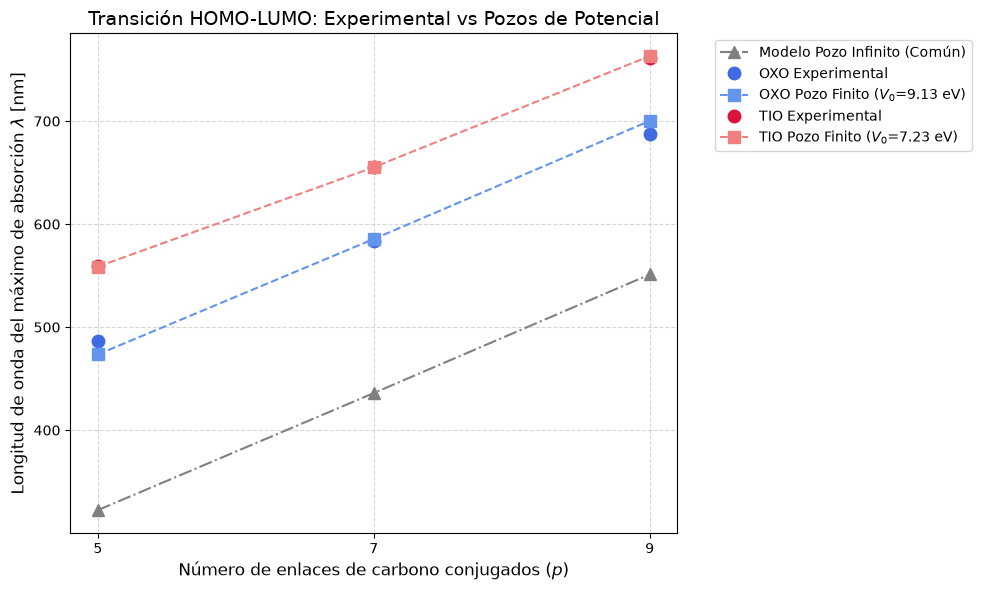

In [5]:
# --- 5. Cálculo del Pozo Infinito y Gráfico Final ---

def get_infinite_well_transition(p):
    """Calcula la transición HOMO-LUMO para el pozo infinito en nm."""
    n_electrons = p + 3
    homo = n_electrons // 2
    lumo = homo + 1
    L = get_chain_length(p) * 1e-9 # Longitud de la caja en metros
    delta_E_eV = (lumo**2 - homo**2) * (np.pi**2 * hbar**2) / (2 * m_e * L**2)
    return swap_ev_and_nm(delta_E_eV)

p_values = [5, 7, 9]

# Datos experimentales
lambda_exp_oxo = [spectrums_mu_d['OXO'][p] for p in p_values]
lambda_exp_tio = [spectrums_mu_d['TIO'][p] for p in p_values]

# Predicciones Pozo Finito
lambda_theo_oxo = [swap_ev_and_nm(get_homo_lumo_transition(get_cyanines_fsw_energies(v0_oxo, p), p)) for p in p_values]
lambda_theo_tio = [swap_ev_and_nm(get_homo_lumo_transition(get_cyanines_fsw_energies(v0_tio, p), p)) for p in p_values]

# Predicciones Pozo Infinito (Es igual para ambas familias)
lambda_inf = [get_infinite_well_transition(p) for p in p_values]

# --- Configuración del gráfico ---
plt.figure(figsize=(10, 6))

# Curva Pozo Infinito
plt.plot(p_values, lambda_inf, '^-.', color='gray', markersize=8, label='Modelo Pozo Infinito (Común)')

# Curvas OXO Cianinas
plt.plot(p_values, lambda_exp_oxo, 'o', color='royalblue', markersize=9, label='OXO Experimental')
plt.plot(p_values, lambda_theo_oxo, 's--', color='cornflowerblue', markersize=8, label=f'OXO Pozo Finito ($V_0$={v0_oxo:.2f} eV)')

# Curvas TIO Cianinas
plt.plot(p_values, lambda_exp_tio, 'o', color='crimson', markersize=9, label='TIO Experimental')
plt.plot(p_values, lambda_theo_tio, 's--', color='lightcoral', markersize=8, label=f'TIO Pozo Finito ($V_0$={v0_tio:.2f} eV)')

# Detalles visuales
plt.xticks(p_values)
plt.xlabel('Número de enlaces de carbono conjugados ($p$)', fontsize=12)
plt.ylabel('Longitud de onda del máximo de absorción $\lambda$ [nm]', fontsize=12)
plt.title('Transición HOMO-LUMO: Experimental vs Pozos de Potencial', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()